**Import necessary packages**

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

**The command to print all columns of a dataframe**

In [274]:
pd.set_option('display.max_columns', None) #to show all columns when we print the dataframe

**Read the dataset (already having distance)**

In [275]:
dataset = pd.read_csv("dataset_with_distance.csv")
dataset.shape

(608800, 26)

**Read mobilisation data**

In [276]:
mobi_21_24 = pd.read_csv("../Mobilisation/LFB Mobilisation data from 2021 - 2024.csv", 
                         usecols = ["IncidentNumber", "TravelTimeSeconds", "TurnoutTimeSeconds", "DateAndTimeMobilised", "DateAndTimeMobile",  "DateAndTimeArrived", "PumpOrder"])
mobi_25_26 = pd.read_csv("../Mobilisation/LFB Mobilisation data from 2025.csv", 
                         usecols = ["IncidentNumber", "TravelTimeSeconds", "TurnoutTimeSeconds", "DateAndTimeMobilised", "DateAndTimeMobile",  "DateAndTimeArrived", "PumpOrder"])
print(mobi_21_24.shape, mobi_25_26.shape)

(727747, 7) (240744, 7)


**Create merged mobilisation data**

In [277]:
mobi = pd.concat([mobi_21_24, mobi_25_26], ignore_index = True)
mobi.shape

(968491, 7)

**Mobilisation with PumpOrder = 1**

In [278]:
mobi_first_arrived = mobi[mobi.PumpOrder == 1 ]
mobi_first_arrived.shape

(624536, 7)

**Drop PumpOrder column, to avoid redundency in the temp dataset in the subsequent codecell**

In [279]:
mobi_first_arrived = mobi_first_arrived.drop(columns = ["PumpOrder"])

**Merge the dataset with mobilisation data to create a temp dataset**

In [280]:
temp_dataset = dataset.merge(mobi_first_arrived, how = "left", on = "IncidentNumber")
temp_dataset.shape

(611876, 31)

**Drop duplicates and missing values in the temp dataset**

In [281]:
temp_dataset = temp_dataset.drop_duplicates()
temp_dataset.dropna()
temp_dataset.shape

(608800, 31)

In [282]:
temp_dataset.head()

,index,IncidentNumber,CalYear,Month,Weekday,Hour,Is_Nightshift,Is_Rush_Hour,Is_Weekend,Is_Public_Holiday,AttendanceTimeSeconds,DeployedFromStation_Name,PumpOrder,IncidentGroup,Is_SpecialService,SpecialServiceType,PropertyCategory,PropertyType,IncGeo_BoroughName,NumCalls,Is_RepeatedCall,Latitude,Longitude,distance_fire_to_station,avg_speed,NumOfCalls_bucket,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds
0,0,000004-01012021,2021,1,4,0,1,0,0,1,181,HORNSEY,1,False Alarm,0,NoSpecialService,Non Residential,Single shop,HARINGEY,1.0,0,51.590249,-0.143203,1490.3,50,1,01/01/2021 00:06,01/01/2021 00:07,01/01/2021 00:09,48.0,133.0
1,1,000005-01012021,2021,1,4,0,1,0,0,1,250,WOODFORD,1,Fire,0,NoSpecialService,Outdoor,Tree scrub,REDBRIDGE,1.0,0,51.606914,0.030447,1166.4,50,1,01/01/2021 00:07,01/01/2021 00:09,01/01/2021 00:11,114.0,136.0
2,2,000006-01012021,2021,1,4,0,1,0,0,1,376,DAGENHAM,1,False Alarm,0,NoSpecialService,Outdoor,Road surface/pavement,BARKING AND DAGENHAM,1.0,0,51.540143,0.154479,3463.6,50,1,01/01/2021 00:08,01/01/2021 00:10,01/01/2021 00:14,131.0,245.0
3,3,000007-01012021,2021,1,4,0,1,0,0,1,409,WANDSWORTH,1,False Alarm,0,NoSpecialService,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,WANDSWORTH,4.0,1,51.446439,-0.214895,1975.6,50,4-5,01/01/2021 00:12,01/01/2021 00:13,01/01/2021 00:19,53.0,356.0
4,4,000009-01012021,2021,1,4,0,1,0,0,1,362,STRATFORD,1,Fire,0,NoSpecialService,Road Vehicle,Car,NEWHAM,2.0,1,51.547241,0.023549,1049.4,50,2,01/01/2021 00:14,01/01/2021 00:16,01/01/2021 00:20,106.0,256.0


**Check correlation coefficient between distance and attendence time**

In [283]:
np.corrcoef(temp_dataset.distance_fire_to_station, temp_dataset.AttendanceTimeSeconds)

array([[1.       , 0.6434996],
       [0.6434996, 1.       ]])

**Delete rows where TravelTime = 0**

In [284]:
temp_dataset = temp_dataset.drop(temp_dataset[temp_dataset.TravelTimeSeconds == 0].index)
temp_dataset.shape

(608635, 31)

**Drop missing value of TravelTime**

In [285]:
temp_dataset = temp_dataset.dropna(subset = ["TravelTimeSeconds"])
temp_dataset.shape

(596595, 31)

**Compute average speed for each row**

In [286]:
temp_dataset["avg_speed"] = (temp_dataset["distance_fire_to_station"]/1000)/(temp_dataset["TravelTimeSeconds"]/3600)


**Describe the column of avg_speed**

In [287]:
print(temp_dataset.avg_speed.describe())

print(f"\n99% quantile of speed: {temp_dataset.avg_speed.quantile(0.99)}")

print(f"\n1% quantile of speed: {temp_dataset.avg_speed.quantile(0.01)}")

count    596595.000000
mean         56.879331
std         379.863159
min           0.000000
25%          25.105928
50%          32.899500
75%          41.524615
max       72071.280000
Name: avg_speed, dtype: float64

99% quantile of speed: 341.3488499999986

1% quantile of speed: 6.978456548856549


**Remove outliers to properly visualize the avg_speed**

In [288]:
temp_dataset = temp_dataset[temp_dataset.avg_speed < temp_dataset.avg_speed.quantile(0.99)]
temp_dataset.shape

(590629, 31)

In [289]:
temp_dataset[temp_dataset.avg_speed < 10][["distance_fire_to_station", "TravelTimeSeconds", "avg_speed"]].head(10)


,distance_fire_to_station,TravelTimeSeconds,avg_speed
45,412.6,302.0,4.918411
102,1352.5,764.0,6.373037
173,620.3,255.0,8.757176
394,189.2,110.0,6.192000
480,2855.9,1142.0,9.002837
481,2104.8,921.0,8.227231
485,1725.3,641.0,9.689672
513,380.2,187.0,7.319358
587,281.8,102.0,9.945882
712,1098.2,697.0,5.672195


**Visualize the distance, time and speed**

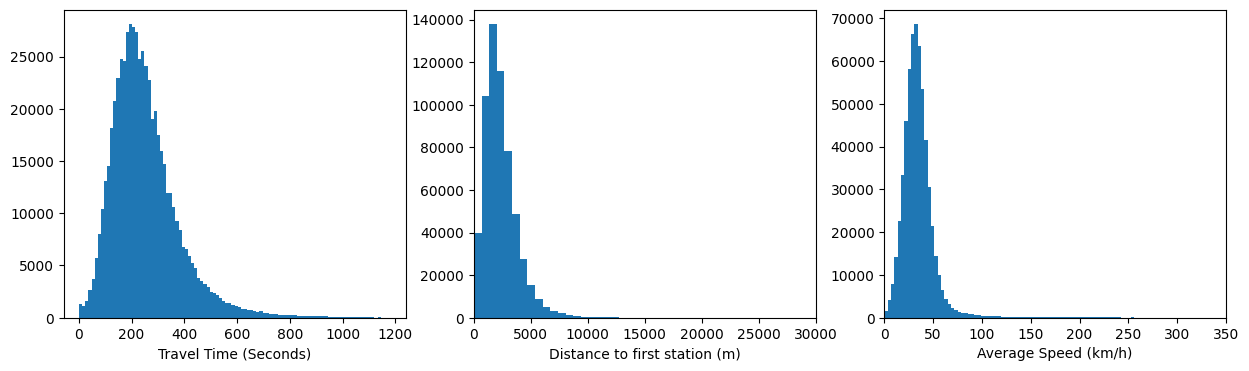

In [290]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(temp_dataset.TravelTimeSeconds, bins = 100)
axes[0].set_xlabel("Travel Time (Seconds)")

axes[1].hist(temp_dataset.distance_fire_to_station, bins = 100) 
axes[1].set_xlim(0, 30000)
axes[1].set_xlabel("Distance to first station (m)")

axes[2].hist(temp_dataset.avg_speed, bins = 100)
axes[2].set_xlim(0, 350)
axes[2].set_xlabel("Average Speed (km/h)")

plt.savefig("distance_time_speed_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Computing IQR for distance and speed**

In [291]:
print(temp_dataset.shape)
q1_distance = temp_dataset.distance_fire_to_station.quantile(0.25)
q3_distance = temp_dataset.distance_fire_to_station.quantile(0.75)  
iqr_distance = q3_distance - q1_distance    
distance_cut_off_lower = q1_distance - 1.5 * iqr_distance
distance_cut_off_upper = q3_distance + 1.5 * iqr_distance

q1_speed = temp_dataset.avg_speed.quantile(0.25)
q3_speed = temp_dataset.avg_speed.quantile(0.75)        
iqr_speed = q3_speed - q1_speed
speed_cut_off_lower = q1_speed - 1.5 * iqr_speed
speed_cut_off_upper = q3_speed + 1.5 * iqr_speed

print(f"For distance")
print(f"Q1: {round(q1_distance, 2)}, Q3: {round(q3_distance, 2)}, IQR: {round(iqr_distance, 2)}, Lower cut-off: {round(distance_cut_off_lower, 2)}, Upper cut-off: {round(distance_cut_off_upper, 2)} ")

print(f"\nFor speed")
print(f"Q1: {round(q1_speed, 2)}, Q3: {round(q3_speed, 2)}, IQR: {round(iqr_speed, 2)}, Lower cut-off: {round(speed_cut_off_lower, 2)}, Upper cut-off: {round(speed_cut_off_upper, 2)} ")

temp_dataset[(temp_dataset.distance_fire_to_station >= distance_cut_off_lower) & (temp_dataset.distance_fire_to_station <= distance_cut_off_upper) 
                            & (temp_dataset.avg_speed >= speed_cut_off_lower) & (temp_dataset.avg_speed <= speed_cut_off_upper)].shape

(590629, 31)
For distance
Q1: 1362.5, Q3: 3037.7, IQR: 1675.2, Lower cut-off: -1150.3, Upper cut-off: 5550.5 

For speed
Q1: 25.02, Q3: 41.19, IQR: 16.17, Lower cut-off: 0.76, Upper cut-off: 65.45 


(552943, 31)

**Define cut-off values for distance and speed**

In [292]:
distance_lower_bound = 200  # 200 meters
distance_upper_bound = 20000  # 20 km

avg_speed_lower_bound = 2 # 2 km/h
avg_speed_upper_bound = 100  # 100 km/h

cleaned_dataset = temp_dataset[(temp_dataset.TravelTimeSeconds >= travel_time_lower_bound) & (temp_dataset.TravelTimeSeconds <= travel_time_upper_bound) 
                            & (temp_dataset.distance_fire_to_station >= distance_lower_bound) & (temp_dataset.distance_fire_to_station <= distance_upper_bound) 
                            & (temp_dataset.avg_speed >= avg_speed_lower_bound) & (temp_dataset.avg_speed <= avg_speed_upper_bound)]
cleaned_dataset.shape

(564706, 31)

**Correlation between distance and attendence time**

In [293]:
np.corrcoef(cleaned_dataset.distance_fire_to_station, cleaned_dataset.AttendanceTimeSeconds)

array([[1.        , 0.69811166],
       [0.69811166, 1.        ]])

**Correlation between distance and travel time**

In [294]:
np.corrcoef(cleaned_dataset.distance_fire_to_station, cleaned_dataset.TravelTimeSeconds)

array([[1.        , 0.71987156],
       [0.71987156, 1.        ]])

**Drop unnecessary columns to have same structure as in previous step**

In [295]:
cleaned_dataset = cleaned_dataset.drop(['DateAndTimeMobilised',
       'DateAndTimeMobile', 'DateAndTimeArrived', 'TurnoutTimeSeconds',
       'TravelTimeSeconds'], axis = 1)


**Export to csv file**

In [296]:
cleaned_dataset.to_csv("dataset_with_filtered_distance_speed.csv", index = False)